# **Quantitative analysis**

### Import Libraries

In [8]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    parent_root = project_root.parent
    if (parent_root / "src").exists():
        project_root = parent_root

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Using project root: {project_root}")

Using project root: /home/melki/Desktop/tenx/news-driven-stock-analysis


In [50]:
import talib
import matplotlib.pyplot as plt
import pynance as pn
from src.data_loader import load_data, handle_missing_values
from src.analysis import add_and_plot_moving_averages

ModuleNotFoundError: No module named 'pynance'

In [10]:
# Load the dataset
df = load_data('../data/finance-data/AAPL.csv')
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


In [11]:
# Handle missing values
df = handle_missing_values(df)
df.head()

Checking for missing values...


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


## **Compute Technical Indicators with TA-Lib**

### Moving Averages (MA)

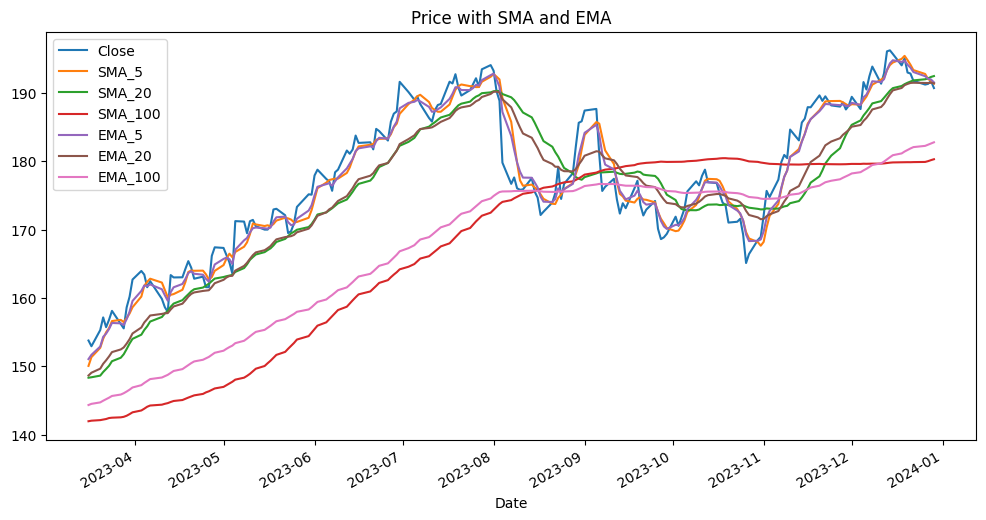

In [12]:
windows = [5, 20, 100]
df = add_and_plot_moving_averages(df, windows)

### Relative Strength Index (RSI)

The **RSI** is a momentum oscillator (typically over a 14-day period) that measures the speed and magnitude of recent price changes on a scale from **0 to 100**.

- **RSI > 70** → often considered **overbought** (price may be stretched to the upside).
- **RSI < 30** → often considered **oversold** (price may be stretched to the downside).

#### Interpretation Notes
- Overbought/oversold levels are **signals of potential reversal**, not guarantees.
- In strong trends, RSI can remain above 70 or below 30 for extended periods.
- Combining RSI with trend context (e.g., moving averages) helps reduce false signals.

RSI_signal
neutral       3132
overbought     574
oversold        68
Name: count, dtype: int64


RSI_signal
neutral       3132
overbought     574
oversold        68
Name: count, dtype: int64


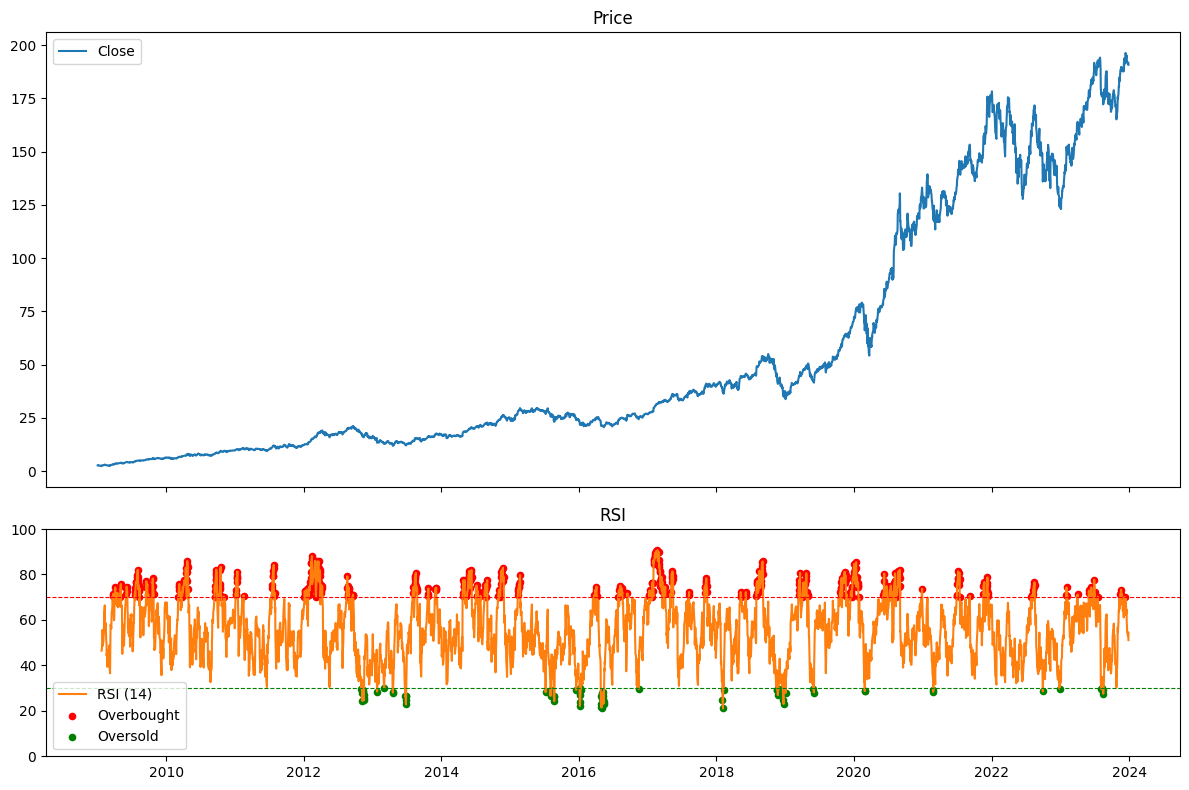

### MACD (Moving Average Convergence Divergence)

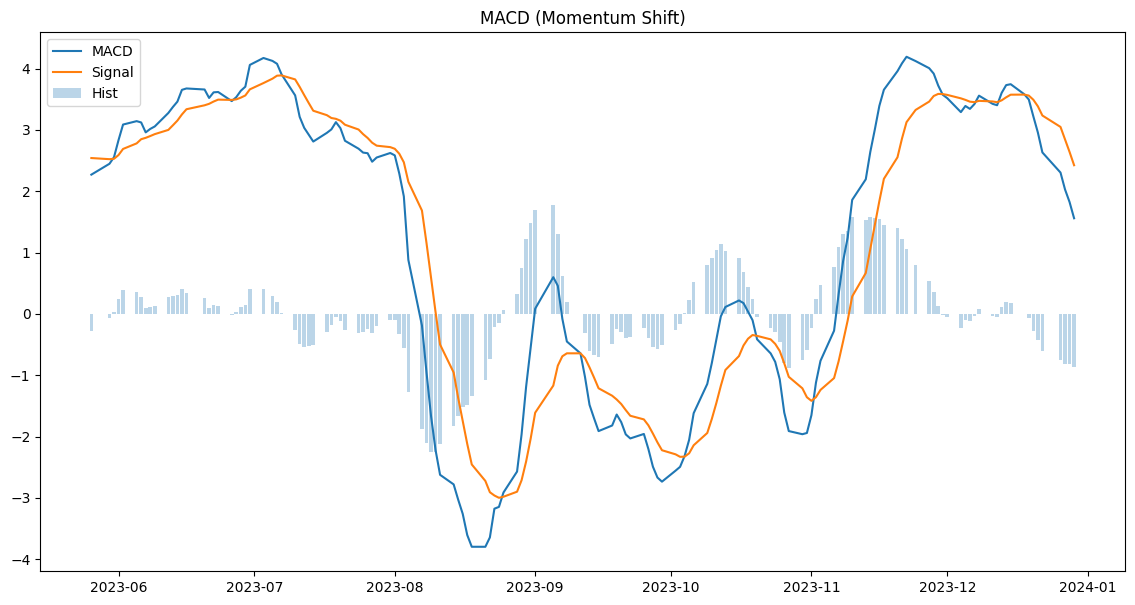

In [31]:
df['macd'], df['macdsignal'], df['macdhist'] = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

plt.figure(figsize=(14, 7))
plt.plot(df.index[-150:], df['macd'][-150:], label='MACD')
plt.plot(df.index[-150:], df['macdsignal'][-150:], label='Signal')
plt.bar(df.index[-150:], df['macdhist'][-150:], label='Hist', alpha=0.3)
plt.title("MACD (Momentum Shift)")
plt.legend()

## **Financial Metrics**

In [44]:
try:
    df['SMA_50_pn'] = pn.tech.sma(df['Close'], window=50)
    plt.plot(df.index[-150:], df['Close'][-150:], label='Close')
    plt.plot(df.index[-150:], df['SMA_50_pn'][-150:], label='50 SMA (PyNance)')
    plt.title("PyNance Technical Indicators")
    plt.legend()
    plt.show()
except Exception as e:
    print(f"PyNance SMA error: {e}.")

PyNance SMA error: name 'pn' is not defined.
